# NB18 — Foundation Forecasting Model Inference Exploration

Lightweight exploratory notebook testing inference workflows with pretrained forecasting foundation models.

The objective is not production benchmarking, but understanding how pretrained transformer-based forecasting systems may fit into future forecasting pipelines.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

from chronos import ChronosPipeline

In [7]:
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",
    dtype="auto"
)

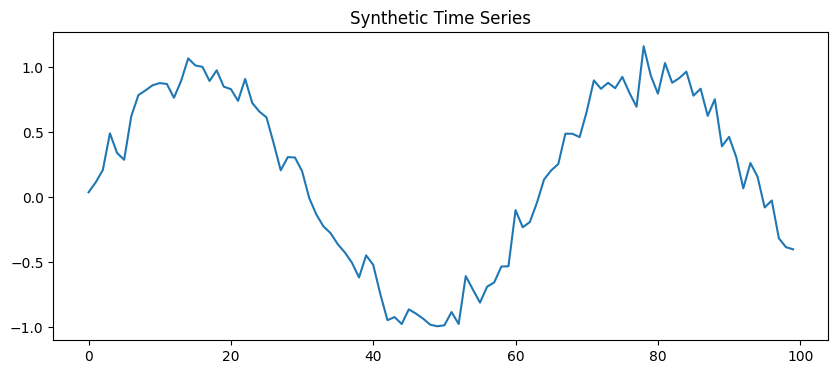

In [8]:
series = np.sin(np.arange(100) * 0.1)

series = series + np.random.normal(0, 0.1, 100)

series = pd.Series(series)

series.plot(figsize=(10, 4))
plt.title("Synthetic Time Series")
plt.show()

In [9]:
context = torch.tensor(series.values, dtype=torch.float32)

forecast = pipeline.predict(
    context,
    prediction_length=24
)

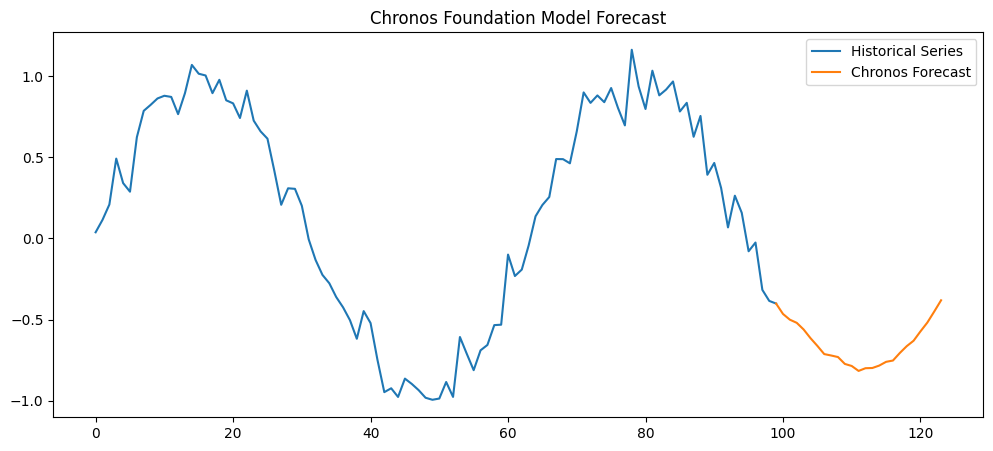

In [10]:
forecast_mean = forecast[0].mean(axis=0).numpy()

future_index = np.arange(len(series), len(series) + 24)

plt.figure(figsize=(12, 5))
plt.plot(series.index, series.values, label="Historical Series")

forecast_x = np.arange(len(series) - 1, len(series) + 24)

forecast_y = np.concatenate([
    [series.values[-1]],
    forecast_mean
])

plt.plot(
    forecast_x,
    forecast_y,
    label="Chronos Forecast"
)

plt.legend()
plt.title("Chronos Foundation Model Forecast")
plt.show()

# Engineering Notes

This notebook explored a lightweight inference workflow using a pretrained forecasting foundation model.

Key observations:

- transformer-based forecasting workflows are heavier than classical tabular pipelines
- pretrained forecasting systems may become useful in irregular or heterogeneous forecasting scenarios
- inference workflows require tensor preparation and dedicated runtime dependencies
- operational integration and monitoring remain important challenges
- further experimentation would be required for real production evaluation